In [154]:
from pathlib import Path
import os
import ast
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint

import csv
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sweep.config import SWEEP_CSV_FIELDNAMES


In [155]:
BASE_RESULTS_PATH = Path("~/Projects/groundwater/results/fno_simple_henry_sweep").expanduser()
DATASET_NAME = "grid_scenarios_lag10_20x40"

results_path = BASE_RESULTS_PATH / DATASET_NAME
pprint([p.name for p in results_path.iterdir() if not p.name.startswith(".")])

['model_weights', 'figures', 'predictions', 'sweep_results.csv']


In [156]:
results_csv_path = results_path / "sweep_results.csv"
summary_results = pd.read_csv(results_csv_path)

results_summary = summary_results.sort_values(by=['scenario_name', 'total_params'])
# results_summary.groupby(['scenario_name', 'model_size_label']).agg({'run_timestamp': 'count'}).sort_values('run_timestamp', ascending=False)

results_summary

,run_timestamp,scenario_name,model_size_label,total_params,rel_l2_error_concentration_train,rel_l2_error_hydraulic_head_train,rel_l2_error_concentration_val,rel_l2_error_hydraulic_head_val
0,2026-09-11T07:14:18,scenario_01,tiny,5718,0.304817,0.696787,0.304051,0.686210
16,2026-09-11T07:18:13,scenario_01,small,26922,0.180051,0.370613,0.183291,0.370446
32,2026-09-11T07:23:14,scenario_01,medium,134770,0.124368,0.229982,0.144142,0.252537
48,2026-09-11T07:28:53,scenario_01,large,1056994,0.061872,0.150736,0.077766,0.188252
64,2026-09-11T07:36:03,scenario_01,huge,4022098,0.053323,0.118603,0.081331,0.180404
...,...,...,...,...,...,...,...,...
31,2026-09-11T07:18:17,scenario_16,small,26922,0.359498,0.561082,0.403891,0.562964
47,2026-09-11T07:23:19,scenario_16,medium,134770,0.089297,0.104215,0.099005,0.118259
63,2026-09-11T07:28:57,scenario_16,large,1056994,0.042481,0.062580,0.064255,0.087864
79,2026-09-11T07:36:07,scenario_16,huge,4022098,0.021686,0.035998,0.036107,0.053110


In [157]:
model_sizes = results_summary[['model_size_label', 'total_params']].drop_duplicates().sort_values(by='total_params', ascending=True).reset_index(drop=True)
model_sizes

,model_size_label,total_params
0,tiny,5718
1,small,26922
2,medium,134770
3,large,1056994
4,huge,4022098
5,massive,11547058


# Plot loss curve

Processing model size: tiny with total params: 5718
Processing model size: small with total params: 26922
Processing model size: medium with total params: 134770
Processing model size: large with total params: 1056994
Processing model size: huge with total params: 4022098
Processing model size: massive with total params: 11547058
Processing model size: tiny with total params: 5718
Processing model size: small with total params: 26922
Processing model size: medium with total params: 134770
Processing model size: large with total params: 1056994
Processing model size: huge with total params: 4022098
Processing model size: massive with total params: 11547058


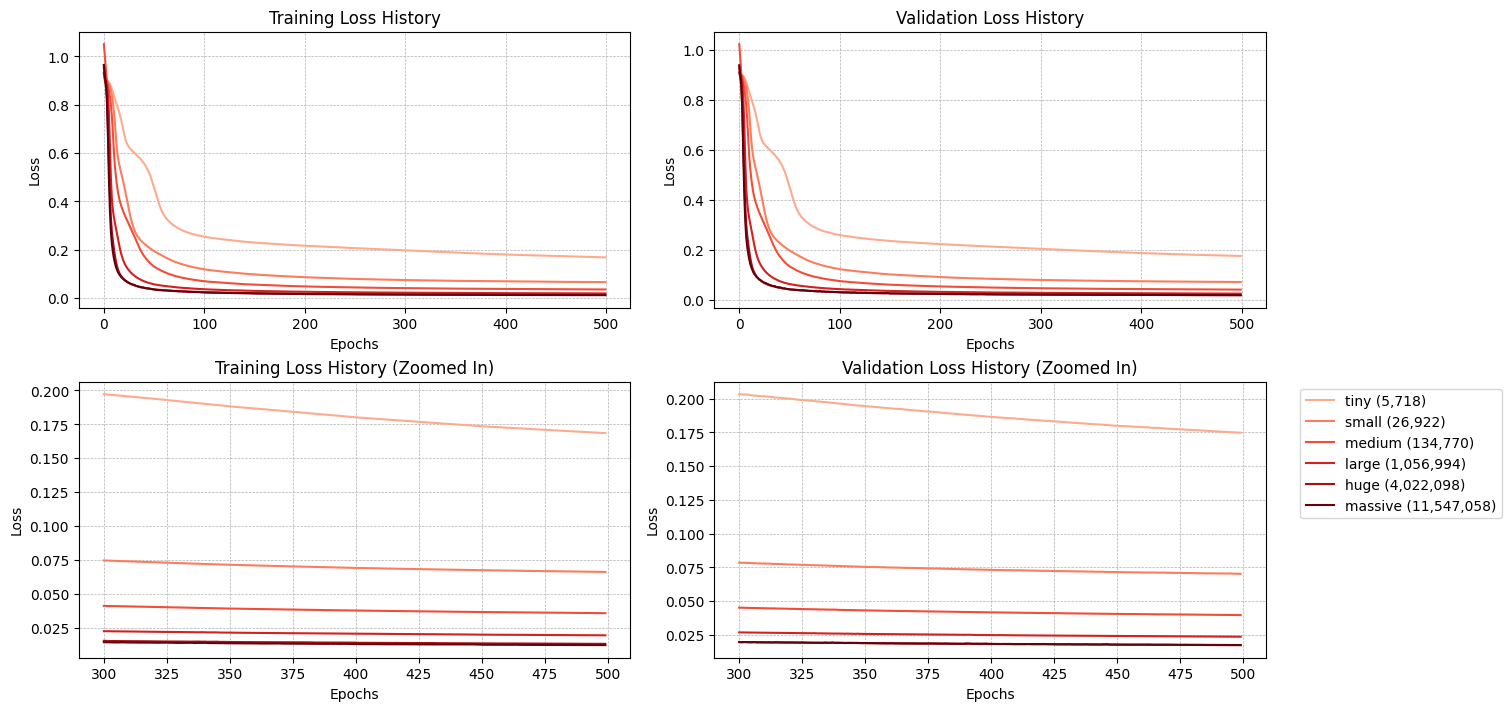

In [158]:
loss_history_parent_dir = results_path / "figures"
loss_history_files = [p.name for p in loss_history_parent_dir.iterdir() if not p.name.startswith(".")]

fig, ax = plt.subplots(2, 2, figsize=(15, 7), constrained_layout=True)
start_index = 0
end_index = 500
colors = plt.cm.Reds(np.linspace(0.3, 1, len(model_sizes)))

for (idx, model_size, total_params) in model_sizes.itertuples(index=True):
    print(f"Processing model size: {model_size} with total params: {total_params}")
    model_loss_history_file = f"{model_size}_loss_history.json"
    json_file_path = loss_history_parent_dir / model_loss_history_file
    if json_file_path.exists():
        with open(json_file_path, 'r') as f:
            loss_history = json.load(f)

        ax[0, 0].plot(np.arange(start_index, end_index), loss_history['train_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])
        ax[0, 1].plot(np.arange(start_index, end_index), loss_history['val_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])

ax[0, 0].set_title("Training Loss History")
ax[0, 0].set_xlabel("Epochs")
ax[0, 0].set_ylabel("Loss")
ax[0, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0, 1].set_title("Validation Loss History")
ax[0, 1].set_xlabel("Epochs")
ax[0, 1].set_ylabel("Loss")
ax[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)


start_index = 300
end_index = 500


for (idx, model_size, total_params) in model_sizes.itertuples(index=True):
    print(f"Processing model size: {model_size} with total params: {total_params}")
    model_loss_history_file = f"{model_size}_loss_history.json"
    json_file_path = loss_history_parent_dir / model_loss_history_file
    if json_file_path.exists():
        with open(json_file_path, 'r') as f:
            loss_history = json.load(f)

        ax[1, 0].plot(np.arange(start_index, end_index), loss_history['train_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])
        ax[1, 1].plot(np.arange(start_index, end_index), loss_history['val_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])

ax[1, 0].set_title("Training Loss History (Zoomed In)")
ax[1, 0].set_xlabel("Epochs")
ax[1, 0].set_ylabel("Loss")
ax[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[1, 1].set_title("Validation Loss History (Zoomed In)")
ax[1, 1].set_xlabel("Epochs")
ax[1, 1].set_ylabel("Loss")
ax[1, 1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0)) # location outside the plot

fig.savefig(results_path / "figures" / "loss_history_summary.png", bbox_inches='tight', dpi=300)




        

# Error vs Model Size

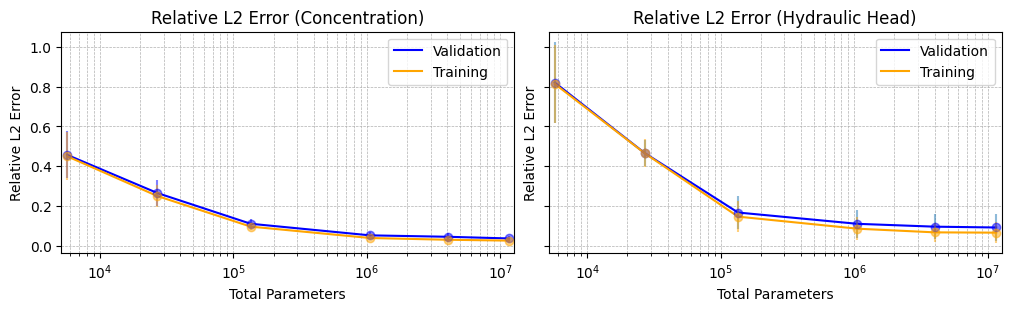

In [159]:
agg_metrics = {
    'rel_l2_error_concentration_train': ['mean', 'std'],
    'rel_l2_error_concentration_val': ['mean', 'std'],
    'rel_l2_error_hydraulic_head_train': ['mean', 'std'],
    'rel_l2_error_hydraulic_head_val': ['mean', 'std'],
}

results_summary_agg_metrics = results_summary.groupby(['model_size_label', 'total_params']).agg(agg_metrics).sort_values(by='total_params', ascending=True).reset_index()
results_summary_agg_metrics.columns = ['_'.join(col).strip('_') for col in results_summary_agg_metrics.columns.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharex=True, sharey=True, constrained_layout=True)

ax[0].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_val_mean'], label='Validation', color='blue')
ax[0].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_val_mean'], yerr=results_summary_agg_metrics['rel_l2_error_concentration_val_std'], fmt='o', color='blue', alpha=0.5)
ax[0].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_train_mean'], label='Training', color='orange')
ax[0].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_train_mean'], yerr=results_summary_agg_metrics['rel_l2_error_concentration_train_std'], fmt='o', color='orange', alpha=0.5)

ax[0].set_title("Relative L2 Error (Concentration)")
ax[0].set_xlabel("Total Parameters")
ax[0].set_ylabel("Relative L2 Error")
ax[0].set_xscale('log')
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].legend()

ax[1].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_mean'], label='Validation', color='blue')
ax[1].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_mean'], yerr=results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_std'], fmt='o', markerfacecolor='blue', markeredgecolor='blue', alpha=0.5)
ax[1].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_mean'], label='Training', color='orange')
ax[1].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_mean'], yerr=results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_std'], fmt='o', color='orange', alpha=0.5)
ax[1].set_title("Relative L2 Error (Hydraulic Head)")
ax[1].set_xlabel("Total Parameters")
ax[1].set_ylabel("Relative L2 Error")
ax[1].set_xscale('log')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[1].set_xlim(results_summary_agg_metrics['total_params'].min() * 0.9, results_summary_agg_metrics['total_params'].max() * 1.1)
ax[1].legend()

fig.savefig(results_path / "figures" / "error_summary.png", bbox_inches='tight', dpi=300)


# Error Scaling (Per Scenario)

In [70]:
BASE_DATA_PATH = Path("~/Projects/groundwater/data/simple_henry_data").expanduser()
data_path = BASE_DATA_PATH / DATASET_NAME

scenarios_manifest_path = data_path / "scenarios_manifest.json"
scenarios_manifest = json.load(open(scenarios_manifest_path, 'r'))['scenarios']
scenarios_manifest_df = pd.DataFrame(scenarios_manifest)[['scenario_index', 'beta_c', 'diffc']]
scenarios_manifest_df


,scenario_index,beta_c,diffc
0,1,0.01,0.00001
1,2,0.01,0.00010
2,3,0.01,0.01000
3,4,0.01,0.10000
4,5,0.05,0.00001
5,6,0.05,0.00010
6,7,0.05,0.01000
7,8,0.05,0.10000
8,9,0.10,0.00001
9,10,0.10,0.00010


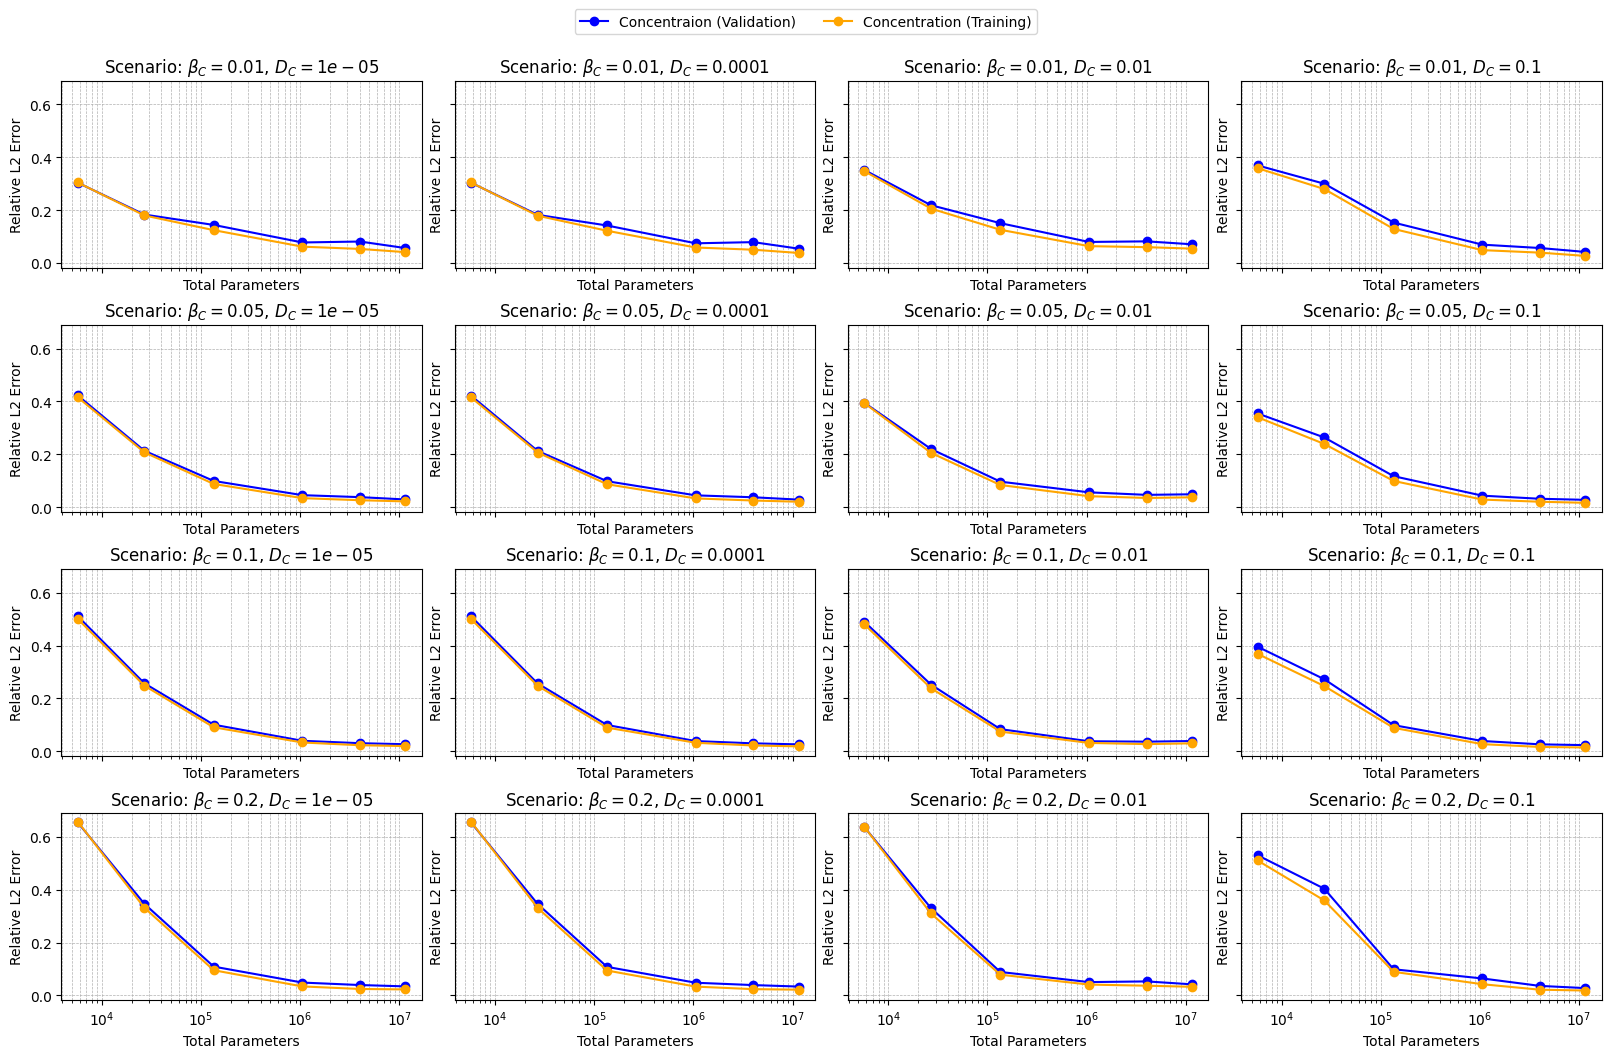

In [160]:
fig, ax = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    scenario_data = results_summary[results_summary['scenario_name'] == scenario_name]
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
    scenario_beta_c = scenario_manifest['beta_c']
    scenario_diffc = scenario_manifest['diffc']

    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_val'], label='Validation', color='blue', marker='o',)
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_train'], label='Training', color='orange', marker='o',)
    # ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_val'], label='Validation', color='blue', linestyle='--', marker='x')
    # ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_train'], label='Training', color='orange', linestyle='--', marker='x')

    ax[ax_idx, ax_idy].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
    ax[ax_idx, ax_idy].set_xlabel("Total Parameters")
    ax[ax_idx, ax_idy].set_ylabel("Relative L2 Error")
    ax[ax_idx, ax_idy].set_xscale('log')
    ax[ax_idx, ax_idy].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0, 0].get_legend_handles_labels()
labels = ['Concentraion (Validation)', 'Concentration (Training)'] #, 'Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

fig.savefig(results_path / "figures" / "error_summary_by_scenario.png", bbox_inches='tight', dpi=300)

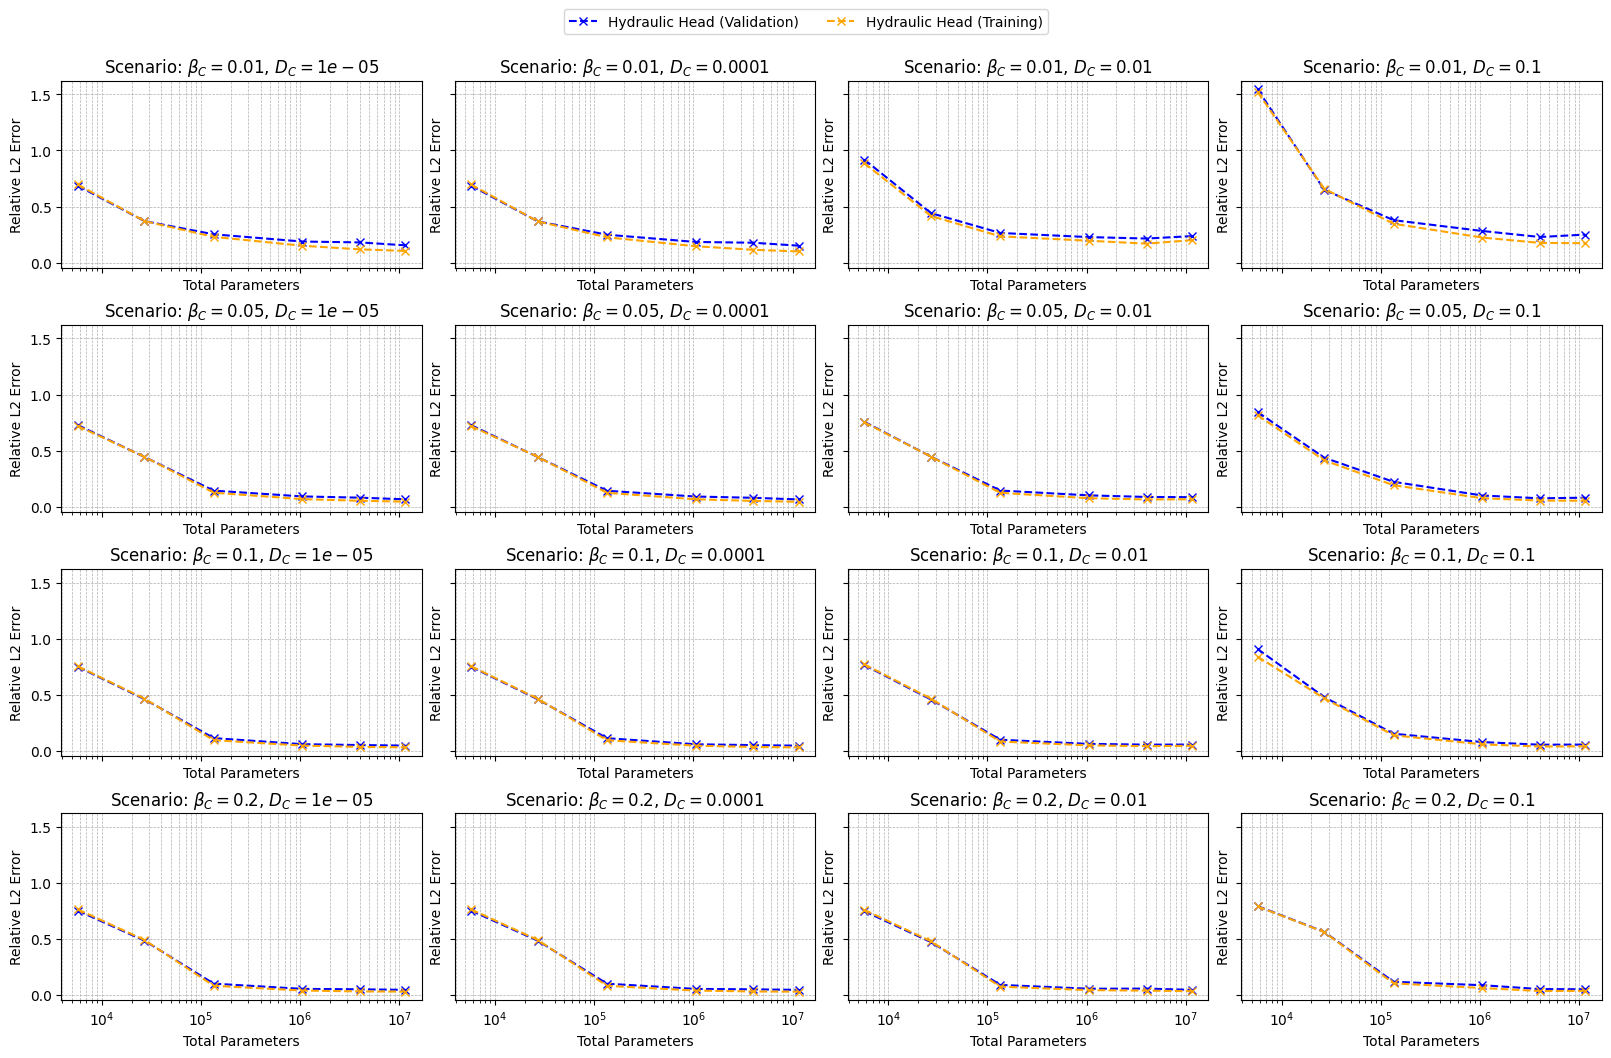

In [82]:
fig, ax = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    scenario_data = results_summary[results_summary['scenario_name'] == scenario_name]
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
    scenario_beta_c = scenario_manifest['beta_c']
    scenario_diffc = scenario_manifest['diffc']
    
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_val'], label='Validation', color='blue', linestyle='--', marker='x')
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_train'], label='Training', color='orange', linestyle='--', marker='x')

    ax[ax_idx, ax_idy].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
    ax[ax_idx, ax_idy].set_xlabel("Total Parameters")
    ax[ax_idx, ax_idy].set_ylabel("Relative L2 Error")
    ax[ax_idx, ax_idy].set_xscale('log')
    ax[ax_idx, ax_idy].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0, 0].get_legend_handles_labels()
labels = ['Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

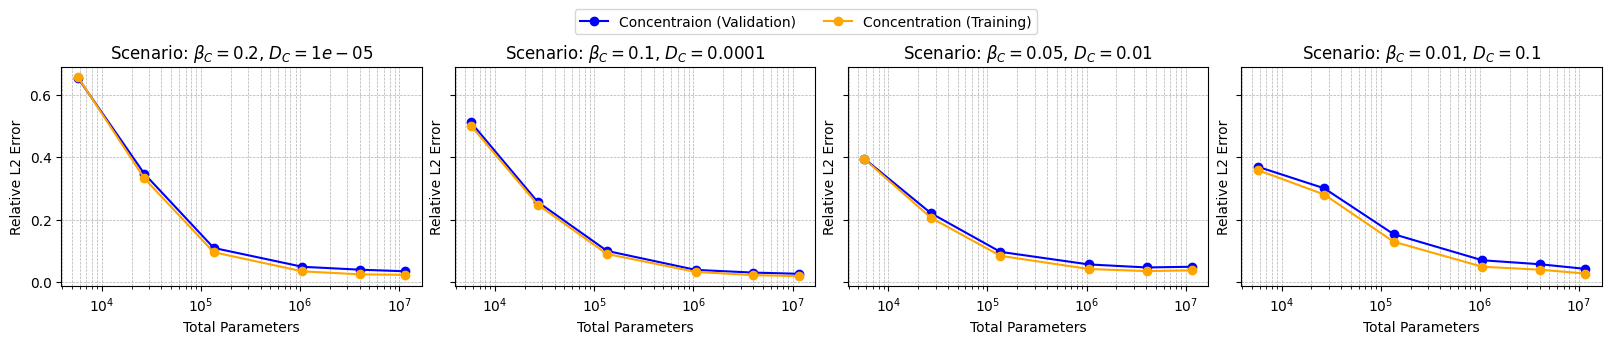

In [161]:
# Plot the right diagonal of the 4x4 grid for hydraulic head errors
fig, ax = plt.subplots(1, 4, figsize=(16, 3), sharex=True, sharey=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):

    idx = (scenario_idx) // 4
    idy = (scenario_idx) % 4

    if idx + idy == 3:  # Only plot for the right diagonal
        scenario_data = results_summary[results_summary['scenario_name'] == scenario_name]

        scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
        scenario_beta_c = scenario_manifest['beta_c']
        scenario_diffc = scenario_manifest['diffc']
        
        ax[scenario_idx % 4].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_val'], label='Validation', color='blue', linestyle='-', marker='o')
        ax[scenario_idx % 4].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_train'], label='Training', color='orange', linestyle='-', marker='o')

        ax[scenario_idx % 4].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
        ax[scenario_idx % 4].set_xlabel("Total Parameters")
        ax[scenario_idx % 4].set_ylabel("Relative L2 Error")
        ax[scenario_idx % 4].set_xscale('log')
        ax[scenario_idx % 4].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0].get_legend_handles_labels()
labels = ['Concentraion (Validation)', 'Concentration (Training)'] #, 'Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.12))

fig.savefig(results_path / "figures" / "error_summary_by_scenario_diagonal.png", bbox_inches='tight', dpi=300)

# Compare Simulated and Predicted Concentration Fields

In [95]:
diag_scenarios = []
for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    idx = (scenario_idx) // 4
    idy = (scenario_idx) % 4

    if idx + idy == 3:  # Only plot for the right diagonal
        diag_scenarios.append(scenario_name)

diag_scenarios

['scenario_04', 'scenario_07', 'scenario_10', 'scenario_13']

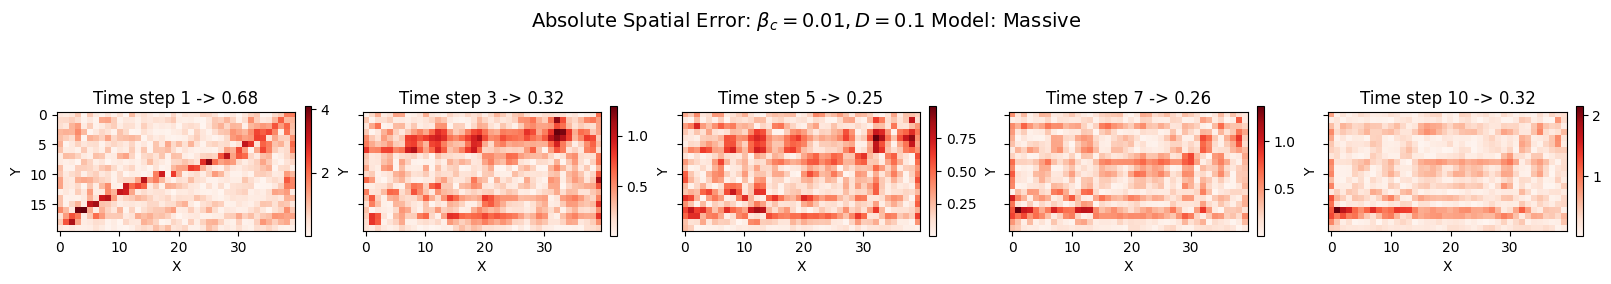

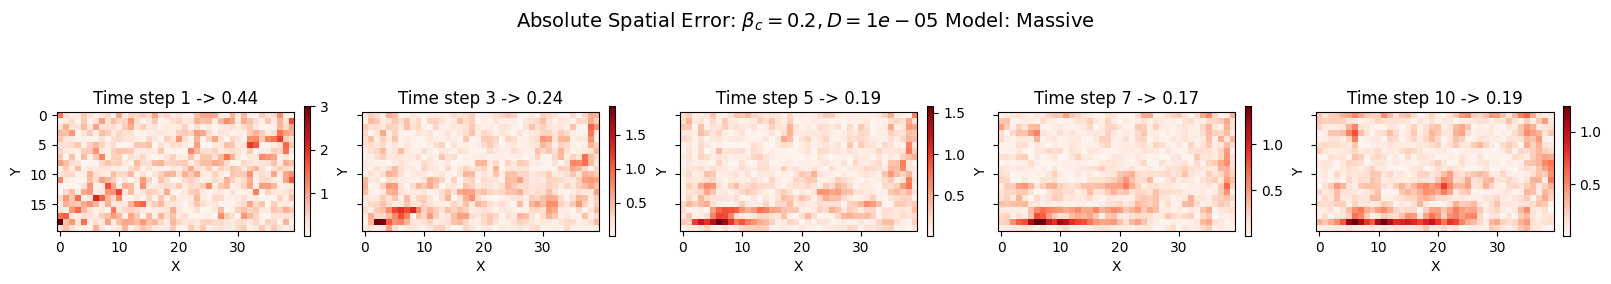

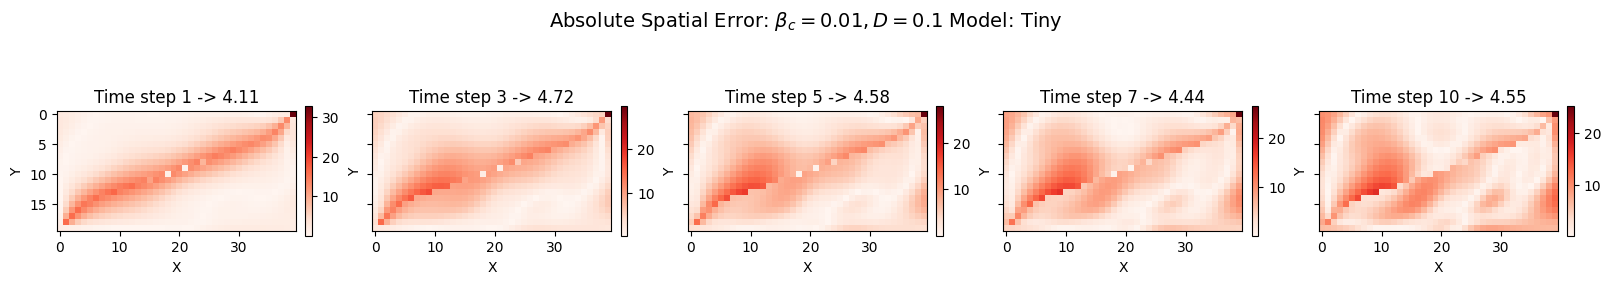

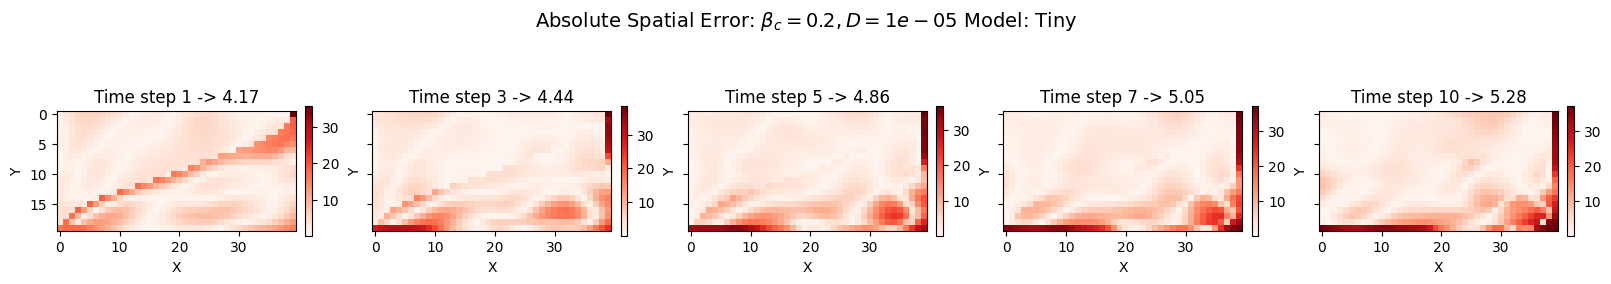

In [162]:
prediction_npz_dir = results_path / "predictions"
scenarios_for_preds =  diag_scenarios[:1]+diag_scenarios[-1:]
model_sizes_for_preds = model_sizes['model_size_label'].tolist()
model_sizes_for_preds = model_sizes_for_preds[:1]+model_sizes_for_preds[-1:]

npz_files = [p for p in prediction_npz_dir.iterdir() if p.suffix == '.npz' and '_'.join(p.name.split('_')[0:2]) in scenarios_for_preds and p.name.split('_')[-1].split('.')[0] in model_sizes_for_preds]
npz_files.sort(key=lambda x: (x.name.split('_')[-1], int(x.name.split('_')[1])))

for npz_file in npz_files:

    # print(f"Loading predictions from: {npz_file.name}")

    data = np.load(npz_file)
    val_preds_rollout = data['val_preds_rollout']
    val_targets = data['val_targets']

    scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == int(npz_file.name.split('_')[1])].iloc[0]
    beta_c = scenario_manifest['beta_c']
    diffc = scenario_manifest['diffc']

    model_size_label = npz_file.name.split('_')[-1].split('.')[0]

    run_idx = 5
    T = val_preds_rollout.shape[1]
    ts_to_plot = np.linspace(0, T-1, 5, dtype=int)
    fig, ax = plt.subplots(1, 5, figsize=(16, 3), sharex=True, sharey=True, constrained_layout=True)

    for idx, t in enumerate(ts_to_plot):
        aerror = np.abs(val_preds_rollout[run_idx, t, :, :, 0] - val_targets[run_idx, t, :, :, 0])
        im = ax[idx].imshow(aerror, cmap='Reds')
        ax[idx].set_title(f'Time step {t+1} -> {aerror.mean():.2f}')
        ax[idx].set_ylabel('Y')
        ax[idx].set_xlabel('X')
        fig.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04, shrink=0.5)
        

    fig.suptitle(f"Absolute Spatial Error: $\\beta_c={beta_c}, D={diffc}$ Model: {model_size_label.capitalize()}", fontsize=14)

    fig.savefig(results_path / "figures" / f"abs_spatial_error_scenario_{npz_file.name.split('_')[1]}_model_{model_size_label}.png", bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()